# Gradient-boosting baselines: LightGBM and XGBoost

CS3244 Group 1 · Gradient Boosting slot (Person 4).

This notebook trains and evaluates the two gradient-boosted tree baselines on
the team's frozen SARC splits, under the same protocol as the NB/LR notebook
(`modelling/probabilistic_linear/nb_logreg_baselines.ipynb`) so the numbers
are directly comparable:

- **Data**: the shared cleaned splits in `data/splits/`, read through
  `pipeline/load.py`. Row counts and row identities are audited against the
  split card and against the NB/LR run before anything is fitted.
- **Text**: sparse word/bigram TF-IDF fed straight to the trees. No SVD.
- **Selection**: Optuna search on `sarc_random` validation ROC-AUC with early
  stopping. Test partitions are scored once, after every choice is fixed.
- **Generalisation**: frozen-hyper-parameter refits on `sarc_temporal` and
  `sarc_subreddit`; frozen-model transfer to four non-SARC corpora.
- **Explanation**: exact TreeSHAP for XGBoost and Saabas path attributions for
  LightGBM (exact TreeSHAP overflows on LightGBM's very deep trees; see A9).
- **Handoff**: row-aligned probability tables for the ensemble slot, in the
  same format as the NB/LR tables.

Part A defines everything. Part B runs it: with `RUN_TRAINING = False` (the
default) it only displays the committed results, so the notebook opens in
seconds; set it to `True` to reproduce the whole experiment.

## Part A — Experiment implementation
### A1. Repository and run switches

In [1]:
from pathlib import Path
import sys, json
from IPython.display import display, Image, Markdown

ROOT = Path.cwd().resolve()
while not (ROOT / "pipeline" / "load.py").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
assert (ROOT / "pipeline" / "load.py").exists(), "Open this notebook inside the repository."

RUN_TRAINING = False  # True: audit, tune, fit, evaluate, explain and export from the shared splits
RUN_OOF = False       # True: also build GroupKFold out-of-fold predictions for stacking
print("Repository:", ROOT.name)  # folder name only; the full path is machine-specific
print("Mode:", "retrain" if RUN_TRAINING else "review saved completed run")

Repository: CS3244
Mode: review saved completed run


### A2. Libraries and fixed experimental settings

In [2]:
"""LightGBM / XGBoost baselines on the team's frozen SARC splits.

Only the shared, cleaned split files are read. Vocabulary, subreddit encoding,
hyper-parameters, early stopping and thresholds use train/validation only;
test partitions are scored once, after every choice is fixed.
"""
from __future__ import annotations

import gc
import hashlib
import importlib.metadata
import os
import platform
import subprocess
import time
import warnings

import joblib
import lightgbm as lgb
import numpy as np
import optuna
import pandas as pd
import xgboost as xgb
from scipy import sparse
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import (
    accuracy_score, average_precision_score, brier_score_loss, confusion_matrix,
    f1_score, precision_recall_curve, precision_score, recall_score,
    roc_auc_score, roc_curve,
)
from sklearn.model_selection import GroupKFold

sys.path.insert(0, str(ROOT / "pipeline"))
from load import load_split, MODEL_SAFE_FEATURES, EXCLUDED_FEATURES  # noqa: E402

SEED = 3244
NAME = "gbdt"
RESULTS = ROOT / "results" / NAME
MODELS = ROOT / "models" / NAME      # git-ignored: fitted boosters and feature builders
FIGURES = ROOT / "figures" / NAME
CACHE = ROOT / ".cache" / NAME       # git-ignored: Optuna study database
TARGET_PRECISION = 0.75              # same operating point as the NB/LR and glass-box slots
TARGETS = ["figlang_reddit", "figlang_twitter", "tweeteval_irony", "news_headlines"]
SCHEMES = ("sarc_random", "sarc_temporal", "sarc_subreddit")
EXPECTED = {
    "sarc_random": (639638, 137066, 137065),
    "sarc_temporal": (484447, 182441, 242091),
    "sarc_subreddit": (639838, 135123, 135534),
    "figlang_reddit": (3729, 659, 1756),
    "figlang_twitter": (4028, 711, 1715),
    "tweeteval_irony": (2853, 950, 780),
    "news_headlines": (19862, 4256, 4257),
}

# Reply-only surface counts (identical list to the NB/LR slot) and the five
# parent-context fields. Together they are exactly MODEL_SAFE_FEATURES.
SURFACE = [c for c in MODEL_SAFE_FEATURES
           if not c.startswith("parent_") and c != "len_ratio_to_parent"]
CONTEXT = ["parent_n_words", "parent_n_chars", "parent_is_empty",
           "parent_jaccard", "len_ratio_to_parent"]
assert set(SURFACE) | set(CONTEXT) == set(MODEL_SAFE_FEATURES)
assert not (set(SURFACE) | set(CONTEXT)) & set(EXCLUDED_FEATURES)

# Feature budget, fixed by the pilot described in the README (full sarc_random
# train, validation AUC). Going from 10k to 20k reply terms helped both
# libraries; XGBoost was flat across 32/64/128 histogram bins while its GPU
# memory rose from 4.5 to 7.8 GB, and past the 8 GB card it spills into shared
# system memory and slows twenty-fold. Hence 32 bins and depth <= 8 for the GPU.
# Trees need no scaling or binning of inputs, so numeric fields stay raw.
REPLY_VOCAB = 20_000
PARENT_VOCAB = 5_000
MAX_BIN = {"xgb": 32, "lgbm": 64}
LEARNING_RATE = 0.1
EARLY_STOP = 100
MAX_ROUNDS = 8000
N_THREADS = int(os.environ.get("GBDT_THREADS", os.cpu_count() or 4))
VRAM_GUARD_MIB = 7200                 # abort an XGBoost fit before the card overflows
XGB_HIST_CACHE = 32                   # cached histogram nodes; memory only (identical trees, checked)

FAMILIES = ("xgb", "lgbm")
REPRESENTATIONS = {
    #                                  surface  context  subreddit
    "reply_tfidf":                    (False,   False,   False),
    "reply_tfidf_surface":            (True,    False,   False),
    "reply_tfidf_surface_context":    (True,    True,    False),
    "reply_tfidf_surface_subreddit":  (True,    False,   True),
}
MAIN_REPS = ("reply_tfidf", "reply_tfidf_surface")
TUNED_REP = "reply_tfidf_surface"    # hyper-parameters are searched here and frozen for every other run
N_TRIALS = 25
TUNE_ROWS = None                      # None = full training partition

warnings.filterwarnings("ignore", category=UserWarning, module="lightgbm")
optuna.logging.set_verbosity(optuna.logging.WARNING)

### A3. Shared data loading and leakage checks

In [3]:
def write_json(path, obj):
    Path(path).write_text(json.dumps(obj, indent=2, ensure_ascii=False,
                                   allow_nan=False, default=str) + "\n", encoding="utf-8")


def text_of(df):
    col = "comment_clean" if "comment_clean" in df else "text_clean"
    return df[col].fillna("").astype(str)


def row_ids(df):
    """Content-derived IDs, identical to the NB/LR handoff tables."""
    return text_of(df).map(lambda s: hashlib.blake2b(s.encode("utf-8"), digest_size=16).hexdigest())


def load_frame(dataset, partition):
    primary = dataset.startswith("sarc_")
    cols = ["comment_clean" if primary else "text_clean", "label"] + SURFACE
    if primary:
        cols += CONTEXT + ["parent_clean", "subreddit", "parent_key"]
    df = load_split(dataset, partition, columns=cols).reset_index(drop=True)
    expected = EXPECTED[dataset][("train", "val", "test").index(partition)]
    if len(df) != expected:
        raise ValueError(f"{dataset}/{partition}: {len(df)} rows, expected {expected}. "
                         "Resolve the data-version mismatch before comparing with teammates.")
    if not df.label.isin([0, 1]).all() or df.label.nunique() != 2:
        raise ValueError("Both binary labels must be present")
    return df


def detect_xgb_device():
    """Use the GPU when XGBoost can train on it; fall back to CPU otherwise."""
    try:
        x = np.random.default_rng(0).normal(size=(64, 3))
        xgb.train({"device": "cuda", "tree_method": "hist"},
                  xgb.DMatrix(x, label=(x[:, 0] > 0).astype(int)), 1)
        return "cuda"
    except xgb.core.XGBoostError:
        return "cpu"


def setup():
    for d in (RESULTS, MODELS, FIGURES, CACHE, RESULTS / "predictions"):
        d.mkdir(parents=True, exist_ok=True)
    versions = {p: importlib.metadata.version(p) for p in
                ("numpy", "pandas", "scipy", "scikit-learn", "pyarrow",
                 "lightgbm", "xgboost", "optuna")}
    versions["python"] = platform.python_version()
    versions["xgboost_device"] = XGB_DEVICE
    versions["lightgbm_device"] = "cpu"
    versions["cpu_threads"] = N_THREADS
    if XGB_DEVICE == "cuda":
        versions["gpu"] = subprocess.run(
            ["nvidia-smi", "--query-gpu=name,memory.total,driver_version", "--format=csv,noheader"],
            capture_output=True, text=True).stdout.strip()
    write_json(RESULTS / "environment.json", versions)
    return versions


def audit_data():
    """Counts, exact row identities and parent groups, checked before any fit.

    The ordered row-ID hashes are compared with the NB/LR slot's own audit, so a
    match proves both slots trained and scored on byte-identical partitions.
    """
    rows = []
    for dataset in EXPECTED:
        ids, groups = {}, {}
        for partition in ("train", "val", "test"):
            df = load_frame(dataset, partition)
            rid = row_ids(df)
            if not rid.is_unique:
                raise ValueError(f"Duplicate text identities: {dataset}/{partition}")
            ids[partition] = set(rid)
            if "parent_key" in df:
                groups[partition] = set(df.parent_key)
            rows.append({"dataset": dataset, "split": partition, "rows": len(df),
                         "positive_rate": float(df.label.mean()),
                         "ordered_row_id_sha256": hashlib.sha256("\n".join(rid).encode()).hexdigest()})
            del df
        for a, b in (("train", "val"), ("train", "test"), ("val", "test")):
            assert not ids[a] & ids[b], f"Text overlap: {dataset} {a}/{b}"
            if groups:
                assert not groups[a] & groups[b], f"Parent overlap: {dataset} {a}/{b}"
    out = pd.DataFrame(rows)
    teammate = ROOT / "results" / "nb_logreg" / "data_audit.csv"
    if teammate.exists():
        ref = pd.read_csv(teammate).set_index(["dataset", "split"]).ordered_row_id_sha256
        out["matches_nb_logreg"] = [ref.get((d, s)) == h for d, s, h in
                                    out[["dataset", "split", "ordered_row_id_sha256"]].itertuples(index=False)]
        if not out.matches_nb_logreg.all():
            raise ValueError("Partitions differ from the NB/LR run; results would not be comparable.")
    out.to_csv(RESULTS / "data_audit.csv", index=False)
    return out


XGB_DEVICE = detect_xgb_device()
print("XGBoost device:", XGB_DEVICE, "| LightGBM device: cpu |", N_THREADS, "CPU threads")

XGBoost device: cuda | LightGBM device: cpu | 16 CPU threads


### A4. Feature construction

One `FeatureBuilder` is fitted per training partition and then applied
unchanged to validation, test and transfer frames. Blocks:

| Block | Columns | Notes |
|---|---|---|
| reply TF-IDF | `REPLY_VOCAB` | 1–2-grams, `min_df=3`, sublinear tf, top terms by corpus frequency |
| surface | 17 | reply-only counts, the same list as NB/LR, left raw |
| context | 5 + `PARENT_VOCAB` | parent length/overlap fields and a parent-text TF-IDF |
| subreddit | 2 | smoothed sarcasm rate (out-of-fold on train) and log frequency |

In a sparse matrix an absent entry is a zero. XGBoost treats it as missing and
learns a default branch for it, which for these non-negative inputs amounts to
a free "zero vs non-zero" split; LightGBM treats it as an ordinary zero.

In [4]:
class SubredditEncoder:
    """Smoothed sarcasm rate and log frequency of each training subreddit.

    Training rows get out-of-fold rates (GroupKFold on `parent_key`, the split
    card's grouping), so no row sees its own label. Other partitions use the
    full training table; unseen communities fall back to the training prior
    with frequency zero. On `sarc_subreddit` every test community is unseen.
    """
    def __init__(self, smoothing=20.0, n_splits=5):
        self.smoothing, self.n_splits = smoothing, n_splits

    def _rate(self, frame, keys):
        prior = float(frame.label.mean())
        table = frame.groupby("subreddit", observed=True).label.agg(["sum", "count"])
        s = table.reindex(keys.to_numpy())
        rate = (s["sum"] + self.smoothing * prior) / (s["count"] + self.smoothing)
        return rate.fillna(prior).to_numpy(np.float32)

    def fit_transform(self, train):
        self.counts_ = train.subreddit.value_counts()
        rate = np.empty(len(train), dtype=np.float32)
        for fit, hold in GroupKFold(self.n_splits).split(train, groups=train.parent_key):
            rate[hold] = self._rate(train.iloc[fit], train.subreddit.iloc[hold])
        self.lookup_ = pd.Series(self._rate(train, self.counts_.index.to_series()),
                                 index=self.counts_.index)
        self.prior_ = float(train.label.mean())
        return np.column_stack([rate, self._freq(train)])

    def _freq(self, df):
        return np.log1p(self.counts_.reindex(df.subreddit.to_numpy()).fillna(0).to_numpy(np.float32))

    def transform(self, df):
        rate = self.lookup_.reindex(df.subreddit.to_numpy()).fillna(self.prior_).to_numpy(np.float32)
        return np.column_stack([rate, self._freq(df)])


class FeatureBuilder:
    """Fitted on one training partition; turns any cleaned frame into a CSR matrix."""

    def __init__(self, representation):
        self.representation = representation
        self.surface, self.context, self.subreddit = REPRESENTATIONS[representation]

    @staticmethod
    def _tfidf(vocab):
        return TfidfVectorizer(ngram_range=(1, 2), min_df=3, sublinear_tf=True,
                               max_features=vocab, dtype=np.float32)

    def fit_transform(self, train):
        self.reply_ = self._tfidf(REPLY_VOCAB).fit(text_of(train))
        if self.context:
            self.parent_ = self._tfidf(PARENT_VOCAB).fit(train.parent_clean.fillna(""))
        sub = None
        if self.subreddit:
            self.subreddit_ = SubredditEncoder()
            sub = self.subreddit_.fit_transform(train)
        return self._assemble(train, sub)

    def transform(self, df):
        sub = self.subreddit_.transform(df) if self.subreddit else None
        return self._assemble(df, sub)

    def _assemble(self, df, sub):
        blocks = [self.reply_.transform(text_of(df))]
        if self.surface:
            blocks.append(sparse.csr_matrix(df[SURFACE].to_numpy(np.float32)))
        if self.context:
            blocks.append(sparse.csr_matrix(df[CONTEXT].to_numpy(np.float32)))
            blocks.append(self.parent_.transform(df.parent_clean.fillna("")))
        if self.subreddit:
            blocks.append(sparse.csr_matrix(sub))
        return sparse.hstack(blocks, format="csr", dtype=np.float32)

    def blocks(self):
        """(block name, feature names) in column order."""
        out = [("text", ["tok:" + t for t in self.reply_.get_feature_names_out()])]
        if self.surface:
            out.append(("surface", list(SURFACE)))
        if self.context:
            out.append(("context", list(CONTEXT)))
            out.append(("context_text", ["parent_tok:" + t for t in self.parent_.get_feature_names_out()]))
        if self.subreddit:
            out.append(("subreddit", ["subreddit_rate", "subreddit_log_freq"]))
        return out

    def feature_names(self):
        return [n for _, names in self.blocks() for n in names]

    def block_of(self):
        return np.array([b for b, names in self.blocks() for _ in names])

### A5. Boosters

Both libraries use their native training APIs with a fixed learning rate of
0.1 and early stopping on validation AUC (patience 100). XGBoost runs on the
GPU when one is available (`device="cuda"`); LightGBM runs on all CPU cores,
because its OpenCL GPU path gives no speed-up on wide sparse text matrices.
When a run is asked for a fixed number of trees (stress refits, OOF folds),
no validation data are used at all.

On the GPU a callback polls `nvidia-smi` every 50 rounds and aborts the fit if
the card's used memory passes `VRAM_GUARD_MIB`; a tuning trial that trips it
is recorded as pruned instead of letting the driver page to system memory.
XGBoost's histogram cache is capped at 32 nodes. GPU histograms use exact
fixed-point sums, so this changes memory only: a 300-round fit with and
without the cap gave bit-identical margins. It is what lets the 25,022-column
parent-context representation (43 non-zeros per row on average, up to 939)
fit in 8 GB.

In [5]:
def xgb_params(params):
    return {"objective": "binary:logistic", "eval_metric": "auc", "tree_method": "hist",
            "device": XGB_DEVICE, "eta": LEARNING_RATE, "max_bin": MAX_BIN["xgb"], "seed": SEED,
            "max_cached_hist_node": XGB_HIST_CACHE, "nthread": N_THREADS, **params}


def lgb_params(params):
    return {"objective": "binary", "metric": "auc", "learning_rate": LEARNING_RATE,
            "max_bin": MAX_BIN["lgbm"], "seed": SEED, "deterministic": True, "force_col_wise": True,
            "num_threads": N_THREADS, "verbose": -1, **params}


class GpuMemoryExceeded(RuntimeError):
    pass


class VramGuard(xgb.callback.TrainingCallback):
    """Stop an XGBoost fit before it outgrows the GPU's own memory."""

    def __init__(self, limit_mib=VRAM_GUARD_MIB, every=50):
        super().__init__()
        self.limit, self.every, self.peak = limit_mib, every, 0

    def after_iteration(self, model, epoch, evals_log):
        if epoch % self.every:
            return False
        out = subprocess.run(["nvidia-smi", "--query-gpu=memory.used", "--format=csv,noheader,nounits"],
                             capture_output=True, text=True).stdout.split()
        used = int(out[0]) if out else 0
        self.peak = max(self.peak, used)
        if used > self.limit:
            raise GpuMemoryExceeded(f"GPU memory {used} MiB > guard {self.limit} MiB at round {epoch}")
        return False


def lgbm_saabas(booster, x, n_trees):
    """Saabas path attributions for a LightGBM booster.

    Each row's path through each tree credits every split's change in node value
    (child minus parent) to the split's feature; the root values form the bias.
    The changes telescope, so a row's attributions sum exactly to its raw score.
    """
    n, n_features = x.shape
    leaves = booster.predict(x, num_iteration=n_trees, pred_leaf=True)
    contrib = np.zeros((n, n_features + 1))
    for t, tree in enumerate(booster.dump_model(num_iteration=n_trees)["tree_info"]):
        root = tree["tree_structure"]
        if "leaf_index" in root:
            contrib[:, n_features] += root["leaf_value"]
            continue
        contrib[:, n_features] += root["internal_value"]
        col = leaves[:, t]
        order = np.argsort(col, kind="stable")
        bounds = np.searchsorted(col[order], np.arange(tree["num_leaves"] + 1))
        stack = [(root, [], [])]
        while stack:
            node, feats, deltas = stack.pop()
            if "leaf_index" in node:
                rows = order[bounds[node["leaf_index"]]:bounds[node["leaf_index"] + 1]]
                if len(rows) and feats:
                    f, inv = np.unique(np.array(feats), return_inverse=True)
                    contrib[np.ix_(rows, f)] += np.bincount(inv, weights=np.array(deltas))
                continue
            for child in (node["left_child"], node["right_child"]):
                value = child["leaf_value"] if "leaf_index" in child else child["internal_value"]
                stack.append((child, feats + [node["split_feature"]],
                              deltas + [value - node["internal_value"]]))
    return contrib


class GBDT:
    """A fitted booster plus the number of trees to use."""

    def __init__(self, family, booster, n_trees):
        self.family, self.booster, self.n_trees = family, booster, int(n_trees)

    def predict(self, x):
        if self.family == "xgb":
            return self.booster.predict(xgb.DMatrix(x), iteration_range=(0, self.n_trees))
        return self.booster.predict(x, num_iteration=self.n_trees)

    def margin(self, x):
        """Raw log-odds score, before the sigmoid."""
        if self.family == "xgb":
            return self.booster.predict(xgb.DMatrix(x), output_margin=True,
                                        iteration_range=(0, self.n_trees))
        return self.booster.predict(x, num_iteration=self.n_trees, raw_score=True)

    def contributions(self, x, method=None):
        """Per-feature log-odds attributions; the last column is the bias term.

        XGBoost: exact TreeSHAP ("treeshap") or Saabas path attribution ("saabas").
        LightGBM: Saabas only, because exact TreeSHAP overflows on its trees
        (see A9). Both always sum, with the bias, to the raw score.
        """
        method = method or ("treeshap" if self.family == "xgb" else "saabas")
        if self.family == "xgb":
            if method == "treeshap":
                return self.booster.predict(xgb.DMatrix(x), pred_contribs=True,
                                            iteration_range=(0, self.n_trees))
            cpu = self.booster.copy()
            cpu.set_param({"device": "cpu"})       # Saabas is CPU-only in XGBoost
            return cpu.predict(xgb.DMatrix(x), pred_contribs=True, approx_contribs=True,
                               iteration_range=(0, self.n_trees))
        assert method == "saabas", "exact TreeSHAP is numerically unstable on these LightGBM trees"
        return lgbm_saabas(self.booster, x, self.n_trees)

    def gain(self, n_features):
        g = np.zeros(n_features)
        if self.family == "xgb":
            for k, v in self.booster.get_score(importance_type="total_gain").items():
                g[int(k[1:])] = v
        else:
            g[:] = self.booster.feature_importance(importance_type="gain", iteration=self.n_trees)
        return g

    def save(self, path):
        path = Path(path)
        if self.family == "xgb":
            self.booster[: self.n_trees].save_model(path.with_suffix(".ubj"))
        else:
            self.booster.save_model(path.with_suffix(".txt"), num_iteration=self.n_trees)

    @classmethod
    def load(cls, family, path, n_trees):
        path = Path(path)
        if family == "xgb":
            booster = xgb.Booster(model_file=str(path.with_suffix(".ubj")))
            booster.set_param({"device": XGB_DEVICE})
        else:
            booster = lgb.Booster(model_file=str(path.with_suffix(".txt")))
        return cls(family, booster, n_trees)


def fit_gbdt(family, params, x_train, y_train, x_val=None, y_val=None, n_trees=None):
    """Early-stop on (x_val, y_val) when given; otherwise grow exactly `n_trees`."""
    assert (x_val is None) != (n_trees is None), "give validation data or a tree count, not both"
    t = time.perf_counter()
    rounds = MAX_ROUNDS if n_trees is None else n_trees
    if family == "xgb":
        bins = MAX_BIN["xgb"]
        dtr = xgb.QuantileDMatrix(x_train, y_train, max_bin=bins)
        evals, extra = [], {}
        if x_val is not None:
            evals = [(xgb.QuantileDMatrix(x_val, y_val, ref=dtr, max_bin=bins), "val")]
            extra = {"early_stopping_rounds": EARLY_STOP}
        callbacks = [VramGuard()] if XGB_DEVICE == "cuda" else []
        booster = xgb.train(xgb_params(params), dtr, num_boost_round=rounds, evals=evals,
                            verbose_eval=False, callbacks=callbacks, **extra)
        used = booster.best_iteration + 1 if x_val is not None else rounds
        vram_peak = callbacks[0].peak if callbacks else None
    else:
        dtr = lgb.Dataset(x_train, y_train, params={"max_bin": MAX_BIN["lgbm"]})
        valid, callbacks = [], []
        if x_val is not None:
            valid = [lgb.Dataset(x_val, y_val, reference=dtr)]
            callbacks = [lgb.early_stopping(EARLY_STOP, verbose=False)]
        booster = lgb.train(lgb_params(params), dtr, num_boost_round=rounds,
                            valid_sets=valid, callbacks=callbacks)
        used = booster.best_iteration if x_val is not None else rounds
        vram_peak = None
    del dtr
    gc.collect()
    model = GBDT(family, booster, used)
    model.vram_peak = vram_peak
    return model, time.perf_counter() - t

### A6. Metrics and validation-only threshold selection

Copied from the NB/LR slot so that every number means the same thing.

In [6]:
def select_threshold(y, p, target=TARGET_PRECISION):
    """Maximise validation recall subject to precision >= target (None if unreachable)."""
    precision, recall, thresholds = precision_recall_curve(y, p)
    good = np.flatnonzero(precision[:-1] >= target)
    if not len(good):
        return None
    best = good[np.argmax(recall[good])]
    return float(thresholds[best])


def scores(y, p, threshold):
    pred = p >= threshold
    tn, fp, fn, tp = confusion_matrix(y, pred, labels=[0, 1]).ravel()
    return {"roc_auc": float(roc_auc_score(y, p)),
            "pr_auc": float(average_precision_score(y, p)),
            "pr_auc_definition": "average_precision",
            "accuracy": float(accuracy_score(y, pred)),
            "precision": float(precision_score(y, pred, zero_division=0)),
            "recall": float(recall_score(y, pred, zero_division=0)),
            "f1": float(f1_score(y, pred, zero_division=0)),
            "brier_score": float(brier_score_loss(y, p)),
            "tn": int(tn), "fp": int(fp), "fn": int(fn), "tp": int(tp)}

### A7. Hyper-parameter search

Optuna's TPE sampler (seeded) searches tree shape, sampling and
regularisation for each library on the tuned representation. Every trial is
a full fit with early stopping, scored by validation ROC-AUC; the tree count
found by early stopping is stored with the trial. Each library's study lives
in its own SQLite file under `.cache/gbdt/`, so an interrupted search resumes
where it stopped and the two libraries can be searched in parallel.

In [7]:
def search_space(family, trial):
    if family == "xgb":
        return {"max_depth": trial.suggest_int("max_depth", 4, 8),
                "min_child_weight": trial.suggest_float("min_child_weight", 1.0, 100.0, log=True),
                "subsample": trial.suggest_float("subsample", 0.5, 1.0),
                "colsample_bytree": trial.suggest_float("colsample_bytree", 0.2, 1.0),
                "lambda": trial.suggest_float("lambda", 1e-3, 30.0, log=True),
                "alpha": trial.suggest_float("alpha", 1e-3, 10.0, log=True)}
    return {"num_leaves": trial.suggest_int("num_leaves", 31, 1023, log=True),
            "min_data_in_leaf": trial.suggest_int("min_data_in_leaf", 10, 500, log=True),
            "feature_fraction": trial.suggest_float("feature_fraction", 0.2, 1.0),
            "bagging_fraction": trial.suggest_float("bagging_fraction", 0.5, 1.0),
            "bagging_freq": 1,
            "lambda_l1": trial.suggest_float("lambda_l1", 1e-3, 10.0, log=True),
            "lambda_l2": trial.suggest_float("lambda_l2", 1e-3, 30.0, log=True)}


def tune(families=FAMILIES, n_trials=N_TRIALS):
    train, val = (load_frame("sarc_random", p) for p in ("train", "val"))
    if TUNE_ROWS and TUNE_ROWS < len(train):
        train = train.sample(n=TUNE_ROWS, random_state=SEED).reset_index(drop=True)
    builder = FeatureBuilder(TUNED_REP)
    xt = builder.fit_transform(train)
    xv = builder.transform(val)
    print(f"tuning matrix {xt.shape}, nnz/row {xt.nnz / xt.shape[0]:.1f}", flush=True)
    path = RESULTS / "selected.json"      # merged, so the two libraries can be tuned in parallel
    for family in families:
        storage = f"sqlite:///{(CACHE / f'optuna_{family}.db').as_posix()}"
        study = optuna.create_study(study_name=f"{family}__{TUNED_REP}", storage=storage,
                                    direction="maximize", load_if_exists=True,
                                    sampler=optuna.samplers.TPESampler(seed=SEED))

        def objective(trial):
            params = search_space(family, trial)
            try:
                model, seconds = fit_gbdt(family, params, xt, train.label, xv, val.label)
            except GpuMemoryExceeded as exc:
                print(f"  {family} trial {trial.number:2d}: pruned, {exc}", flush=True)
                gc.collect()
                raise optuna.TrialPruned(str(exc))
            p = model.predict(xv)
            auc = float(roc_auc_score(val.label, p))
            trial.set_user_attr("n_trees", model.n_trees)
            trial.set_user_attr("fit_seconds", seconds)
            trial.set_user_attr("val_average_precision", float(average_precision_score(val.label, p)))
            print(f"  {family} trial {trial.number:2d}: val AUC {auc:.5f}  trees {model.n_trees:4d}  "
                  f"{seconds:6.0f}s  {params}", flush=True)
            return auc

        done = len([t for t in study.trials if t.state == optuna.trial.TrialState.COMPLETE])
        if done < n_trials:
            study.optimize(objective, n_trials=n_trials - done, gc_after_trial=True)
        best = study.best_trial
        selected = json.loads(path.read_text()) if path.exists() else {}
        selected[family] = {"params": {**best.params, **({"bagging_freq": 1} if family == "lgbm" else {})},
                            "n_trees": best.user_attrs["n_trees"], "val_roc_auc": best.value,
                            "trial": best.number, "representation": TUNED_REP,
                            "train_rows": len(train), "learning_rate": LEARNING_RATE,
                            "max_bin": MAX_BIN[family]}
        write_json(path, selected)
        trials = study.trials_dataframe(attrs=("number", "value", "params", "user_attrs", "state"))
        trials.insert(0, "model", family)
        trials.to_csv(RESULTS / f"tuning_trials_{family}.csv", index=False)
    return json.loads(path.read_text())

### A8. Final fits, stress refits, ablations and transfer

- **sarc_random**: each representation is refitted with the frozen
  hyper-parameters; early stopping on validation picks its tree count, and
  the precision ≥ 0.75 threshold is chosen on the same validation scores.
- **Stress schemes**: a fresh builder and booster on each scheme's own
  training partition, with the hyper-parameters, tree count and threshold all
  frozen from `sarc_random`. Nothing is selected on the stress partitions.
- **Transfer**: the `sarc_random` main models score each target corpus's
  test partition with no target-side fitting or calibration.
- **Ablations**: the context and subreddit blocks are added to the tuned
  representation. Context is evaluated on all three schemes; subreddit is
  also run on `sarc_subreddit`, the only split where its value is honest.

In [8]:
def model_id(dataset, family, representation):
    return f"{dataset}__{family}_{representation}"


def evaluate(model, builder, meta, df, dataset, partition):
    t = time.perf_counter()
    p = model.predict(builder.transform(df))
    infer_seconds = time.perf_counter() - t
    mid = model_id(meta["training_dataset"], meta["model"], meta["representation"])
    pd.DataFrame({"row_id": row_ids(df), "row_position": np.arange(len(df)),
                  "label": df.label.to_numpy(), "probability": p}
                 ).to_parquet(RESULTS / "predictions" / f"{mid}__{dataset}__{partition}.parquet", index=False)
    rows = []
    policies = {"default_0.50": 0.5}
    if meta["threshold"] is not None:
        policies["source_validation_precision_0.75"] = meta["threshold"]
    for policy, threshold in policies.items():
        rows.append({"dataset": dataset, "split": partition, "model": meta["model"],
                     "model_id": mid, "training_dataset": meta["training_dataset"],
                     "representation": meta["representation"], "ngram_max": 2, "seed": SEED,
                     "threshold": threshold, "threshold_policy": policy,
                     "threshold_source": "fixed" if policy == "default_0.50" else "sarc_random/val",
                     "rows": len(df), "train_rows": meta["train_rows"], "n_features": meta["n_features"],
                     "n_trees": model.n_trees, "fit_seconds": meta["fit_seconds"],
                     "inference_seconds": infer_seconds, **scores(df.label, p, threshold)})
    return rows


def run_plan():
    """(dataset, representation) pairs fitted in `fit_and_evaluate`."""
    plan = [(d, r) for d in SCHEMES for r in MAIN_REPS + ("reply_tfidf_surface_context",)]
    plan += [("sarc_random", "reply_tfidf_surface_subreddit"),
             ("sarc_subreddit", "reply_tfidf_surface_subreddit")]
    return plan


def _dump_atomic(obj, path):
    tmp = path.with_name(f"{path.name}.{os.getpid()}.tmp")
    joblib.dump(obj, tmp, compress=3)
    os.replace(tmp, path)


PARTS = CACHE / "parts"   # one metrics/log file per fitted model, so runs resume and parallelise


def merge_fit_outputs():
    """Combine the per-model part files into metrics.csv, fit_log.json and frozen.json."""
    metrics = pd.concat([pd.read_csv(f) for f in sorted(PARTS.glob("metrics__*.csv"))], ignore_index=True)
    order = {d: i for i, d in enumerate(list(SCHEMES) + TARGETS)}
    metrics = metrics.sort_values(["training_dataset", "representation", "model", "dataset", "split",
                                   "threshold_policy"], key=lambda s: s.map(order) if s.name in
                                  ("training_dataset", "dataset") else s, kind="stable")
    metrics.to_csv(RESULTS / "metrics.csv", index=False)
    write_json(RESULTS / "fit_log.json", [json.loads(f.read_text()) for f in sorted(PARTS.glob("fit_log__*.json"))])
    write_json(RESULTS / "frozen.json", {f.stem.split("__", 1)[1]: json.loads(f.read_text())
                                         for f in sorted(PARTS.glob("frozen__*.json"))})
    return metrics


def fit_and_evaluate(selected, families=FAMILIES, plan=None):
    """Fit every planned (dataset, representation) model for the given libraries.

    Each model writes its own part files and is skipped if they already exist,
    so an interrupted run resumes, and the libraries (or single models) can run
    in separate processes. Stress refits read the tree count and threshold that
    the matching sarc_random fit froze.
    """
    PARTS.mkdir(parents=True, exist_ok=True)
    plan = run_plan() if plan is None else plan
    done = lambda d, f, r: (PARTS / f"metrics__{model_id(d, f, r)}.csv").exists()  # noqa: E731
    for dataset in SCHEMES:
        todo = {r: [f for f in families if not done(dataset, f, r)] for d, r in plan if d == dataset}
        if not any(todo.values()):
            continue
        train, val, test = (load_frame(dataset, p) for p in ("train", "val", "test"))
        for representation, fams in todo.items():
            if not fams:
                continue
            builder = FeatureBuilder(representation)
            t = time.perf_counter()
            xt = builder.fit_transform(train)
            feature_seconds = time.perf_counter() - t
            xv = builder.transform(val)
            _dump_atomic(builder, MODELS / f"{dataset}__{representation}__builder.joblib")
            for family in fams:
                params = selected[family]["params"]
                key = f"{family}_{representation}"
                if dataset == "sarc_random":
                    model, seconds = fit_gbdt(family, params, xt, train.label, xv, val.label)
                    frozen = {"n_trees": model.n_trees,
                              "threshold": select_threshold(val.label, model.predict(xv))}
                    write_json(PARTS / f"frozen__{key}.json", frozen)
                else:
                    frozen = json.loads((PARTS / f"frozen__{key}.json").read_text())
                    model, seconds = fit_gbdt(family, params, xt, train.label, n_trees=frozen["n_trees"])
                meta = {"model": family, "representation": representation, "training_dataset": dataset,
                        "threshold": frozen["threshold"], "train_rows": len(train),
                        "n_features": xt.shape[1], "fit_seconds": seconds}
                mid = model_id(dataset, family, representation)
                model.save(MODELS / mid)
                reloaded = GBDT.load(family, MODELS / mid, model.n_trees)
                np.testing.assert_allclose(model.predict(xv[:256]), reloaded.predict(xv[:256]),
                                           rtol=1e-6, atol=1e-7)
                rows = evaluate(model, builder, meta, val, dataset, "val")
                rows += evaluate(model, builder, meta, test, dataset, "test")
                if dataset == "sarc_random" and representation in MAIN_REPS:
                    for target in TARGETS:
                        rows += evaluate(model, builder, meta, load_frame(target, "test"), target, "test")
                write_json(PARTS / f"fit_log__{mid}.json",
                           {"model_id": mid, "fit_seconds": seconds, "feature_seconds": feature_seconds,
                            "n_trees": model.n_trees, "n_features": xt.shape[1],
                            "device": XGB_DEVICE if family == "xgb" else "cpu",
                            "gpu_memory_peak_mib": getattr(model, "vram_peak", None),
                            "early_stopped_on": f"{dataset}/val" if dataset == "sarc_random" else None,
                            "roundtrip_prediction_check": "PASS"})
                pd.DataFrame(rows).to_csv(PARTS / f"metrics__{mid}.csv", index=False)
                v = next(r for r in rows if r["split"] == "val")["roc_auc"]
                te = next(r for r in rows if r["split"] == "test" and r["dataset"] == dataset)["roc_auc"]
                print(f"{mid}: val AUC {v:.5f}  test AUC {te:.5f}  trees {model.n_trees}  fit {seconds:.0f}s",
                      flush=True)
                del model, reloaded
                gc.collect()
            del builder, xt, xv
            gc.collect()
        del train, val, test
        gc.collect()
    return merge_fit_outputs()


def summarise(metrics):
    """Headline, stress, ablation and transfer tables at the 0.50 threshold."""
    m = metrics[metrics.threshold_policy == "default_0.50"]
    test = m[m.split == "test"]
    cols = ["roc_auc", "pr_auc", "accuracy", "precision", "recall", "f1", "brier_score"]
    headline = test[(test.dataset == "sarc_random")][["model", "representation", "n_trees"] + cols]
    base = test[(test.dataset == test.training_dataset)].set_index(["training_dataset", "model", "representation"]).roc_auc
    stress = test[test.dataset == test.training_dataset][["dataset", "model", "representation", "roc_auc", "accuracy", "f1"]].copy()
    stress["auc_delta_vs_random"] = [r.roc_auc - base.get(("sarc_random", r.model, r.representation), np.nan)
                                     for r in stress.itertuples()]
    ablation = []
    for (d, fam, rep), auc in base.items():
        if rep == TUNED_REP:
            continue
        ref = base.get((d, fam, TUNED_REP))
        if ref is not None:
            ablation.append({"dataset": d, "model": fam, "representation": rep, "roc_auc": auc,
                             "tuned_rep_roc_auc": ref, "auc_delta": auc - ref})
    transfer = test[test.dataset.isin(TARGETS)][["dataset", "model", "representation"] + cols]
    out = {"headline": headline.reset_index(drop=True), "stress": stress.reset_index(drop=True),
           "ablation": pd.DataFrame(ablation), "transfer": transfer.reset_index(drop=True)}
    for name, df in out.items():
        df.to_csv(RESULTS / f"{name}.csv", index=False)
    return out

### A9. Explanations: TreeSHAP and Saabas attributions

Attributions are computed for the tuned representation on a fixed 10,000-row
`sarc_random` validation sample (test is never used for explanation). They
are in log-odds and sum, with the bias term, to the model's raw score; the
notebook checks that identity for every model.

- **XGBoost**: exact TreeSHAP, computed natively on the GPU.
- **LightGBM**: Saabas path attribution (each split's change in node value,
  credited to its feature). Exact TreeSHAP is numerically unusable here:
  leaf-wise growth on sparse word features builds comb-shaped trees with a
  median depth of 90 levels (maximum 130), and TreeSHAP's path weights
  overflow on paths that long — LightGBM's own `pred_contrib` returns values
  near 1e16 that no longer sum to the prediction. Saabas involves only sums
  and differences along the path, so it is stable at any depth.
- **Agreement check**: XGBoost can produce both. On the same sample the
  notebook compares XGBoost's exact TreeSHAP with its Saabas attributions
  (`attribution_check.json`), which shows how far the LightGBM numbers can be
  read like SHAP values.

Outputs: mean |attribution| per feature and its share by block; for each
word/bigram, the mean attribution over the rows that contain it (positive =
the model pushes those replies towards sarcastic); and for six surface fields
the mean attribution per observed value, i.e. the learned effect curve.

These describe what the fitted models rely on, conditional on everything else
in the representation; they are not causal effects of the words or cues.

In [9]:
SHAP_ROWS = 10_000
EDA_TOKENS = ["yeah", "because", "obviously", "totally", "clearly", "sure", "wow"]
TOPIC_TOKENS = ["women", "racist", "white"]
SHAPES = ["n_exclam", "n_repeat_punct", "n_interjections", "n_chars", "avg_word_len", "allcaps_ratio"]


SHAPE_MIN_ROWS = 30   # a value bin is plotted only if this many sample rows fall in it


def _shape_bins(values, contrib):
    """Mean attribution per value: small counts one by one (6+ pooled), other fields in 20 quantile bins."""
    v = pd.Series(values)
    if (v.round() == v).all() and v.quantile(0.99) <= 12:
        key = v.clip(upper=6)
    else:
        key = pd.qcut(v, q=20, duplicates="drop")
    g = pd.DataFrame({"key": key, "value": v, "shap": contrib}).groupby("key", observed=True)
    out = g.agg(value=("value", "median"), mean_attr=("shap", "mean"), n=("shap", "size")).reset_index(drop=True)
    return out[out.n >= SHAPE_MIN_ROWS].reset_index(drop=True)


def explain():
    from scipy.stats import spearmanr
    val = load_frame("sarc_random", "val")
    sample = val.sample(n=SHAP_ROWS, random_state=SEED).reset_index(drop=True)
    builder = joblib.load(MODELS / f"sarc_random__{TUNED_REP}__builder.joblib")
    x = builder.transform(sample)
    names, blocks = np.array(builder.feature_names()), builder.block_of()
    is_token = blocks == "text"
    present = (x[:, is_token] != 0).toarray()
    frozen = json.loads((RESULTS / "frozen.json").read_text())
    features, block_rows, token_rows, shape_rows = [], [], [], []
    for family in FAMILIES:
        model = GBDT.load(family, MODELS / model_id("sarc_random", family, TUNED_REP),
                          frozen[f"{family}_{TUNED_REP}"]["n_trees"])
        method = "treeshap" if family == "xgb" else "saabas"
        full = model.contributions(x, method)
        np.testing.assert_allclose(full.sum(axis=1), model.margin(x), rtol=1e-4, atol=1e-3)
        contrib = full[:, :-1]
        mean_abs = np.abs(contrib).mean(axis=0)
        if family == "xgb":   # how closely does Saabas reproduce exact TreeSHAP on the same model?
            saabas_abs = np.abs(model.contributions(x, "saabas")[:, :-1]).mean(axis=0)
            top = np.argsort(-mean_abs)[:200]
            write_json(RESULTS / "attribution_check.json", {
                "model": model_id("sarc_random", "xgb", TUNED_REP), "rows": SHAP_ROWS,
                "spearman_mean_abs_top200": float(spearmanr(mean_abs[top], saabas_abs[top]).statistic),
                "top20_overlap": len(set(np.argsort(-mean_abs)[:20]) & set(np.argsort(-saabas_abs)[:20])),
                "top10_treeshap": [str(n) for n in names[np.argsort(-mean_abs)[:10]]],
                "top10_saabas": [str(n) for n in names[np.argsort(-saabas_abs)[:10]]]})
        gain = model.gain(len(names))
        features.append(pd.DataFrame({"model": family, "attribution": method, "feature": names,
                                      "block": blocks, "mean_abs_attr": mean_abs,
                                      "mean_attr": contrib.mean(axis=0), "gain_share": gain / gain.sum()}))
        share = pd.Series(mean_abs).groupby(blocks).sum()
        for b, v in (share / share.sum()).items():
            block_rows.append({"model": family, "attribution": method, "block": b, "mean_abs_attr_share": v})
        n_present = present.sum(axis=0)
        mean_when_present = np.divide((contrib[:, is_token] * present).sum(axis=0), n_present,
                                      out=np.zeros(len(n_present)), where=n_present > 0)
        token_rows.append(pd.DataFrame({"model": family, "attribution": method, "token": names[is_token],
                                        "n_present": n_present, "mean_attr_when_present": mean_when_present,
                                        "mean_abs_attr": mean_abs[is_token]}))
        for f in SHAPES:
            b = _shape_bins(sample[f].to_numpy(float), contrib[:, list(names).index(f)])
            b.insert(0, "feature", f)
            b.insert(0, "attribution", method)
            b.insert(0, "model", family)
            shape_rows.append(b)
        del full, contrib
        gc.collect()
    feats = pd.concat(features)
    feats["rank"] = feats.groupby("model").mean_abs_attr.rank(ascending=False, method="first").astype(int)
    feats.sort_values(["model", "rank"]).query("rank <= 200").to_csv(RESULTS / "attribution_top_features.csv", index=False)
    pd.DataFrame(block_rows).to_csv(RESULTS / "attribution_block_share.csv", index=False)
    tokens = pd.concat(token_rows)
    tokens["rank"] = tokens.groupby("model").mean_abs_attr.rank(ascending=False, method="first").astype(int)
    watch = tokens[tokens.token.isin(["tok:" + t for t in EDA_TOKENS + TOPIC_TOKENS])].copy()
    watch["group"] = np.where(watch.token.str[4:].isin(EDA_TOKENS), "eda_marker", "topic_word")
    watch.sort_values(["group", "token", "model"]).to_csv(RESULTS / "attribution_watch_tokens.csv", index=False)
    tokens.sort_values(["model", "rank"]).query("rank <= 200").to_csv(RESULTS / "attribution_tokens.csv", index=False)
    pd.concat(shape_rows).to_csv(RESULTS / "attribution_shapes.csv", index=False)
    return feats

### A10. Out-of-fold predictions for stacking (optional)

For a stacking meta-model the ensemble slot needs predictions on rows the
base model did not train on. Five GroupKFold folds over `sarc_random` train,
grouped by `parent_key`; each fold refits the feature builder and booster on
its own four folds, with the frozen hyper-parameters and tree count. The
full-train models' training-set predictions must never be used in their place.

In [10]:
OOF_DIR = CACHE / "oof"   # one array per (fold, model), so the folds resume and parallelise


def make_oof(n_splits=5, families=FAMILIES, folds=None):
    selected = json.loads((RESULTS / "selected.json").read_text())
    frozen = json.loads((RESULTS / "frozen.json").read_text())
    OOF_DIR.mkdir(parents=True, exist_ok=True)
    df = load_frame("sarc_random", "train")
    for fold, (fit, hold) in enumerate(GroupKFold(n_splits).split(df, groups=df.parent_key)):
        todo = [(r, f) for r in MAIN_REPS for f in families
                if (folds is None or fold in folds) and not (OOF_DIR / f"fold{fold}__{f}_{r}.npy").exists()]
        if not todo:
            continue
        tr, ho = df.iloc[fit].reset_index(drop=True), df.iloc[hold].reset_index(drop=True)
        assert not set(tr.parent_key) & set(ho.parent_key)
        for rep in MAIN_REPS:
            fams = [f for r, f in todo if r == rep]
            if not fams:
                continue
            builder = FeatureBuilder(rep)
            xt = builder.fit_transform(tr)
            xh = builder.transform(ho)
            for family in fams:
                model, seconds = fit_gbdt(family, selected[family]["params"], xt, tr.label,
                                          n_trees=frozen[f"{family}_{rep}"]["n_trees"])
                np.save(OOF_DIR / f"fold{fold}__{family}_{rep}.npy", model.predict(xh))
                print(f"OOF fold {fold + 1}/{n_splits} {family} {rep}: {seconds:.0f}s", flush=True)
                del model
                gc.collect()
            del builder, xt, xh
            gc.collect()
    return assemble_oof(df, n_splits)


def assemble_oof(df, n_splits=5):
    """Write the stacking table once every (fold, model) array exists."""
    out = pd.DataFrame({"row_id": row_ids(df), "row_position": np.arange(len(df)),
                        "label": df.label.to_numpy(), "fold": -1})
    for r in MAIN_REPS:
        for f in FAMILIES:
            out[model_id("sarc_random", f, r)] = np.nan
    for fold, (_, hold) in enumerate(GroupKFold(n_splits).split(df, groups=df.parent_key)):
        out.loc[hold, "fold"] = fold
        for r in MAIN_REPS:
            for f in FAMILIES:
                path = OOF_DIR / f"fold{fold}__{f}_{r}.npy"
                if not path.exists():
                    print(f"OOF incomplete: {path.name} missing; table not written yet", flush=True)
                    return None
                out.loc[hold, model_id("sarc_random", f, r)] = np.load(path)
    assert not out.isna().any().any()
    (RESULTS / "ensemble_predictions").mkdir(parents=True, exist_ok=True)
    out.to_parquet(RESULTS / "ensemble_predictions" / "sarc_random__train_oof.parquet", index=False)
    return out

### A11. Ensemble handoff tables

Same layout as the NB/LR slot: one parquet per (dataset, split) with
`row_id`, `row_position`, `label` and one probability column per model,
named `<training dataset>__<model>_<representation>`. Only the two main
representations are exported; ablation predictions stay in the local
`predictions/` folder. Join on `row_id` and check labels; use one split
scheme at a time.

In [11]:
def export_ensemble():
    out_dir = RESULTS / "ensemble_predictions"
    out_dir.mkdir(parents=True, exist_ok=True)
    tables = {}
    for f in sorted((RESULTS / "predictions").glob("*.parquet")):
        training, model_rep, dataset, partition = f.stem.split("__")
        if model_rep.split("_", 1)[1] not in MAIN_REPS:
            continue
        p = pd.read_parquet(f)
        key = (dataset, partition)
        if key not in tables:
            tables[key] = p[["row_id", "row_position", "label"]].copy()
        base = tables[key]
        if not (base.row_id.equals(p.row_id) and base.label.equals(p.label)):
            raise ValueError(f"Row alignment differs for {f.name}")
        base[f"{training}__{model_rep}"] = p.probability.to_numpy()
    index = []
    for (dataset, partition), table in sorted(tables.items()):
        name = f"{dataset}__{partition}.parquet"
        table.to_parquet(out_dir / name, index=False)
        index.append({"dataset": dataset, "split": partition, "file": name, "rows": len(table),
                      "prediction_columns": [c for c in table.columns if "__" in c]})
    oof = out_dir / "sarc_random__train_oof.parquet"
    if oof.exists():
        t = pd.read_parquet(oof, columns=None)
        index.append({"dataset": "sarc_random", "split": "train_oof", "file": oof.name, "rows": len(t),
                      "prediction_columns": [c for c in t.columns if "__" in c],
                      "note": "5-fold GroupKFold(parent_key) out-of-fold predictions for stacking"})
    write_json(out_dir / "index.json", index)
    return pd.DataFrame(index)

### A12. Figures

One colour per model throughout (XGBoost blue, LightGBM orange; the pair
passes the colour-vision-deficiency checks), the NB/LR logistic regression in
neutral grey as the reference. Every plotted number is also in a CSV under
`results/gbdt/`.

In [12]:
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt  # noqa: E402

INK = {"surface": "#fcfcfb", "primary": "#0b0b0b", "secondary": "#52514e", "muted": "#898781",
       "grid": "#e1e0d9", "axis": "#c3c2b7", "reference": "#898781", "recessive": "#c3c2b7"}
COLOR = {"xgb": "#2a78d6", "lgbm": "#eb6834"}
LABEL = {"xgb": "XGBoost", "lgbm": "LightGBM"}
REP_LABEL = {"reply_tfidf": "text only", "reply_tfidf_surface": "text + surface",
             "reply_tfidf_surface_context": "+ parent context", "reply_tfidf_surface_subreddit": "+ subreddit"}


def _style():
    plt.rcParams.update({
        "figure.facecolor": INK["surface"], "axes.facecolor": INK["surface"],
        "savefig.facecolor": INK["surface"], "font.family": ["Segoe UI", "DejaVu Sans"],
        "font.size": 9.5, "text.color": INK["primary"], "axes.labelcolor": INK["secondary"],
        "axes.edgecolor": INK["axis"], "axes.linewidth": 0.8, "axes.grid": True,
        "grid.color": INK["grid"], "grid.linewidth": 0.6, "axes.axisbelow": True,
        "xtick.color": INK["muted"], "ytick.color": INK["muted"], "xtick.labelcolor": INK["secondary"],
        "ytick.labelcolor": INK["secondary"], "axes.spines.top": False, "axes.spines.right": False,
        "legend.frameon": False, "axes.titleweight": "semibold", "axes.titlesize": 10.5,
        "axes.titlecolor": INK["primary"], "lines.linewidth": 1.6,
    })


def _save(fig, name):
    fig.savefig(FIGURES / name, dpi=160, bbox_inches="tight")
    plt.close(fig)


def fig_roc_pr():
    """G01: ROC and PR curves on sarc_random test, with the NB/LR LR as reference."""
    y, curves = None, []
    for family in FAMILIES:
        for rep in MAIN_REPS:
            p = pd.read_parquet(RESULTS / "predictions" / f"{model_id('sarc_random', family, rep)}__sarc_random__test.parquet")
            y = p.label.to_numpy()
            curves.append((f"{LABEL[family]}, {REP_LABEL[rep]}", p.probability.to_numpy(), COLOR[family],
                           "-" if rep == TUNED_REP else ":"))
    lr = ROOT / "results" / "nb_logreg" / "ensemble_predictions" / "sarc_random__test.parquet"
    if lr.exists():
        t = pd.read_parquet(lr, columns=["row_id", "label", "sarc_random__lr_reply_tfidf_surface"])
        assert t.row_id.equals(p.row_id) and (t.label.to_numpy() == y).all(), "NB/LR rows are not aligned"
        curves.append(("NB/LR slot: LR, text + surface", t.iloc[:, 2].to_numpy(), INK["reference"], "-"))
    fig, (a, b) = plt.subplots(1, 2, figsize=(9.6, 4.2))
    for name, p, color, ls in curves:
        fpr, tpr, _ = roc_curve(y, p)
        prec, rec, _ = precision_recall_curve(y, p)
        lw = 1.2 if color == INK["reference"] else 1.6
        a.plot(fpr, tpr, ls, color=color, lw=lw, label=f"{name} (AUC {roc_auc_score(y, p):.3f})")
        b.plot(rec, prec, ls, color=color, lw=lw, label=f"{name} (AP {average_precision_score(y, p):.3f})")
    a.plot([0, 1], [0, 1], color=INK["axis"], lw=0.8)
    b.axhline(y.mean(), color=INK["axis"], lw=0.8)
    a.set(title="ROC, sarc_random test", xlabel="False-positive rate", ylabel="True-positive rate")
    b.set(title="Precision–recall, sarc_random test", xlabel="Recall", ylabel="Precision", ylim=(0.45, 1.0))
    a.legend(fontsize=7.5, loc="lower right")
    b.legend(fontsize=7.5, loc="lower left")
    _save(fig, "G01_roc_pr.png")


def _grouped_bars(ax, frame, order, value):
    x = np.arange(len(order))
    w = 0.36
    for k, family in enumerate(FAMILIES):
        v = frame[frame.model == family].set_index("dataset").reindex(order)[value]
        ax.bar(x + (k - 0.5) * (w + 0.02), v, width=w, color=COLOR[family], label=LABEL[family])
    ax.set_xticks(x, [o.replace("_", "\n", 1) for o in order])


def fig_generalisation(tables):
    """G02: tuned representation across schemes and, frozen, across corpora."""
    stress = tables["stress"].query("representation == @TUNED_REP")
    transfer = tables["transfer"].query("representation == @TUNED_REP")
    frame = pd.concat([stress[["dataset", "model", "roc_auc"]], transfer[["dataset", "model", "roc_auc"]]])
    order = list(SCHEMES) + TARGETS
    fig, ax = plt.subplots(figsize=(9.6, 3.8))
    _grouped_bars(ax, frame, order, "roc_auc")
    ax.axhline(0.5, color=INK["secondary"], lw=0.8)
    ax.text(len(order) - 0.5, 0.505, "chance", ha="right", va="bottom", color=INK["secondary"], fontsize=8)
    ax.axvline(len(SCHEMES) - 0.5, color=INK["axis"], lw=0.8)
    ax.set(ylim=(0.35, 0.85), ylabel="Test ROC-AUC",
           title="Tuned representation: own-scheme refits (left) and frozen transfer off SARC (right)")
    ax.legend(loc="upper right", ncols=2)
    _save(fig, "G02_generalisation.png")


def fig_ablation(tables):
    """G03: AUC change versus the tuned representation, per scheme."""
    ab = tables["ablation"].copy()
    ab["label"] = ab.dataset + "\n" + ab.representation.map(REP_LABEL)
    order = [f"{d}\n{REP_LABEL[r]}" for d in SCHEMES for r in REPRESENTATIONS
             if r != TUNED_REP and ((ab.dataset == d) & (ab.representation == r)).any()]
    fig, ax = plt.subplots(figsize=(9.6, 3.8))
    x = np.arange(len(order))
    for k, family in enumerate(FAMILIES):
        v = ab[ab.model == family].set_index("label").reindex(order).auc_delta
        ax.bar(x + (k - 0.5) * 0.38, v, width=0.36, color=COLOR[family], label=LABEL[family])
    ax.axhline(0, color=INK["secondary"], lw=0.8)
    ax.set_xticks(x, order, fontsize=8)
    ax.set(ylabel="Δ test ROC-AUC vs text + surface",
           title="Feature-block ablations (hyper-parameters frozen)")
    ax.legend(loc="best")
    _save(fig, "G03_ablation.png")


METHOD_LABEL = {"xgb": "XGBoost (exact TreeSHAP)", "lgbm": "LightGBM (Saabas)"}


def fig_top_features(n=20):
    """G04: top features by mean |attribution|; surface fields highlighted, tokens in grey."""
    feats = pd.read_csv(RESULTS / "attribution_top_features.csv")
    fig, axes = plt.subplots(1, 2, figsize=(9.6, 5.6))
    for ax, family in zip(axes, FAMILIES):
        top = feats[feats.model == family].nsmallest(n, "rank").iloc[::-1]
        colors = [COLOR[family] if b != "text" else INK["recessive"] for b in top.block]
        ax.barh(np.arange(len(top)), top.mean_abs_attr, color=colors, height=0.7)
        ax.set_yticks(np.arange(len(top)), [f.replace("tok:", "") for f in top.feature], fontsize=8)
        ax.set(title=f"{METHOD_LABEL[family]}: top {n}", xlabel="Mean |attribution| (log-odds)")
        ax.grid(axis="y", visible=False)
    handles = [plt.Rectangle((0, 0), 1, 1, color=INK["recessive"]),
               plt.Rectangle((0, 0), 1, 1, color=COLOR["xgb"]),
               plt.Rectangle((0, 0), 1, 1, color=COLOR["lgbm"])]
    fig.legend(handles, ["word / bigram", "surface feature (XGBoost)", "surface feature (LightGBM)"],
               loc="lower center", ncols=3, fontsize=8, bbox_to_anchor=(0.5, -0.03))
    fig.tight_layout(rect=(0, 0.03, 1, 1))
    _save(fig, "G04_top_features.png")


def fig_effect_shapes():
    """G05: learned effect curve (mean attribution per value) for six surface fields."""
    shapes = pd.read_csv(RESULTS / "attribution_shapes.csv")
    fig, axes = plt.subplots(2, 3, figsize=(9.6, 5.4))
    for ax, f in zip(axes.flat, SHAPES):
        for family in FAMILIES:
            s = shapes[(shapes.feature == f) & (shapes.model == family)]
            ax.plot(s.value, s.mean_attr, "-o", color=COLOR[family], ms=3.5, lw=1.4, label=METHOD_LABEL[family])
        ax.axhline(0, color=INK["secondary"], lw=0.8)
        ax.set(title=f, xlabel="value", ylabel="mean attribution" if f in (SHAPES[0], SHAPES[3]) else None)
    axes.flat[0].legend(fontsize=7.5)
    fig.suptitle("Learned effect of surface fields (sarc_random validation sample; > 0 pushes towards sarcastic)",
                 fontsize=10, color=INK["primary"])
    fig.tight_layout()
    _save(fig, "G05_effect_shapes.png")


def make_figures(tables):
    _style()
    fig_roc_pr()
    fig_generalisation(tables)
    fig_ablation(tables)
    fig_top_features()
    fig_effect_shapes()

### A13. Protocol checks

Small, fast checks of the rules the results depend on. They run on every
execution of the notebook, including review mode.

In [13]:
import unittest


class ProtocolChecks(unittest.TestCase):
    def test_feature_lists_are_model_safe(self):
        self.assertFalse((set(SURFACE) | set(CONTEXT)) & set(EXCLUDED_FEATURES))
        self.assertEqual(len(SURFACE), 17)

    def test_threshold_respects_precision_target(self):
        y = np.array([0, 0, 1, 1, 1, 0, 1, 1])
        p = np.array([0.1, 0.4, 0.35, 0.8, 0.7, 0.75, 0.9, 0.6])
        t = select_threshold(y, p, 0.75)
        self.assertGreaterEqual(precision_score(y, p >= t), 0.75)
        self.assertIsNone(select_threshold(np.array([0, 1]), np.array([0.9, 0.1]), 0.99))

    def test_subreddit_encoding_is_out_of_fold(self):
        # Each parent thread is its own subreddit; an out-of-fold rate can only
        # fall back to the other folds' prior, never echo the row's own label.
        df = pd.DataFrame({"subreddit": [f"s{i}" for i in range(10)], "label": [0, 1] * 5,
                           "parent_key": [f"p{i}" for i in range(10)]})
        enc = SubredditEncoder(n_splits=5).fit_transform(df)[:, 0]
        for i, (fit, hold) in enumerate(GroupKFold(5).split(df, groups=df.parent_key)):
            np.testing.assert_allclose(enc[hold], df.label.iloc[fit].mean(), rtol=1e-6)

    def test_row_ids_are_content_hashes(self):
        a = pd.DataFrame({"comment_clean": ["yeah right", "ok"]})
        self.assertEqual(list(row_ids(a)), list(row_ids(a.iloc[::-1]))[::-1])
        self.assertEqual(len(row_ids(a).iloc[0]), 32)

    def test_saved_booster_round_trip(self):
        rng = np.random.default_rng(SEED)
        x = sparse.csr_matrix(rng.random((300, 5), dtype=np.float32))
        y = (x[:, 0].toarray().ravel() > 0.5).astype(int)
        import tempfile
        with tempfile.TemporaryDirectory() as d:
            for family in FAMILIES:
                m, _ = fit_gbdt(family, {}, x, y, n_trees=5)
                m.save(Path(d) / family)
                r = GBDT.load(family, Path(d) / family, 5)
                np.testing.assert_allclose(m.predict(x), r.predict(x), rtol=1e-6)


protocol = unittest.TextTestRunner(verbosity=1).run(
    unittest.defaultTestLoader.loadTestsFromTestCase(ProtocolChecks))
assert protocol.wasSuccessful()

.

.

.

.

.

----------------------------------------------------------------------
Ran 5 tests in 0.220s

OK


## Part B — Run the experiment and inspect the results

With `RUN_TRAINING = False` every cell below only reads files committed under
`results/gbdt/` and `figures/gbdt/`. With `RUN_TRAINING = True` the cells
rerun the full experiment first. Run serially in one kernel that takes about
five hours on an 8 GB laptop GPU and 16 CPU threads; every stage resumes
where it stopped. For the long runs, `run_stages.py` next to this notebook
executes the same code stage by stage from a terminal, with the two libraries
in parallel and one process per XGBoost model, which is how the committed
results were produced (about three and a half hours).

On an 8 GB GPU the memory guard may stop an XGBoost fit late in a single long
kernel, because XGBoost keeps freed GPU memory cached. If that happens, restart
the kernel and run again: finished models, folds and trials are skipped.

## 1. Data audit

Every partition has the split card's row count, no text or parent thread is
shared between train, validation and test, and the ordered row-ID hashes
equal those of the NB/LR run, i.e. both slots used byte-identical data.

In [14]:
if RUN_TRAINING:
    print(setup())
    audit_data()
display(pd.read_csv(RESULTS / "data_audit.csv"))
display(pd.Series(json.loads((RESULTS / "environment.json").read_text())).to_frame("environment"))

,dataset,split,rows,positive_rate,ordered_row_id_sha256,matches_nb_logreg
0,sarc_random,train,639638,0.509069,522ddd07bfa426eb93cd565d322b74c8583f375b25d223...,True
1,sarc_random,val,137066,0.509149,14fd3429907d6c317ee402cb2d99e5e79fd1d9fb6f7ad7...,True
2,sarc_random,test,137065,0.510707,934d0b671bf359389ebe0228cf9d15c4dedbc00bf560b8...,True
3,sarc_temporal,train,484447,0.538191,629f5d59af5c29420a7dca9d1b6c9655e2bc38f84cccd8...,True
4,sarc_temporal,val,182441,0.503779,cdc2d288aa51ce32496c8f610aa4ebc6c6775a1b1d5820...,True
5,sarc_temporal,test,242091,0.457873,047f1c722f2e3c6209694a05ac6c4bbeccf18c737fce7f...,True
6,sarc_subreddit,train,639838,0.511082,1eeb5fc6e692304c5686f166d37faca686aa38000af380...,True
7,sarc_subreddit,val,135123,0.511926,3ec3a685ee8d144374af6c8aba5680fc71d91c1e763f07...,True
8,sarc_subreddit,test,135534,0.499329,8363129ca2e6f74188a54eb3963e50ff3b8af9d382fbd4...,True
9,figlang_reddit,train,3729,0.499866,56fd0f3a4b7c3a485efb8a1b6e9d59c43806fb4fc19c2d...,True


,environment
numpy,2.3.5
pandas,2.2.3
scipy,1.17.0
scikit-learn,1.8.0
pyarrow,25.0.1
lightgbm,4.7.0
xgboost,3.4.1
optuna,5.0.0
python,3.13.16
xgboost_device,cuda


## 2. Hyper-parameter search

The best trial per library on `sarc_random` validation ROC-AUC. These
hyper-parameters are frozen for every later fit.

In [15]:
if RUN_TRAINING:
    tune()
selected = json.loads((RESULTS / "selected.json").read_text())
display(pd.DataFrame({f: {"val_roc_auc": s["val_roc_auc"], "n_trees": s["n_trees"], **s["params"]}
                      for f, s in selected.items()}))

,xgb,lgbm
val_roc_auc,0.803636,0.804407
n_trees,7901.000000,1041.000000
max_depth,7.000000,NaN
min_child_weight,3.415620,NaN
subsample,0.815840,NaN
colsample_bytree,0.737193,NaN
lambda,0.012750,NaN
alpha,2.659459,NaN
num_leaves,NaN,133.000000
min_data_in_leaf,NaN,14.000000


## 3. Final fits, stress refits, ablations and transfer

Headline test numbers on `sarc_random` at the 0.50 threshold:

In [16]:
if RUN_TRAINING:
    fit_and_evaluate(selected)
metrics = pd.read_csv(RESULTS / "metrics.csv")
tables = summarise(metrics)
display(tables["headline"].round(4))

,model,representation,n_trees,roc_auc,pr_auc,accuracy,precision,recall,f1,brier_score
0,lgbm,reply_tfidf,1224,0.7964,0.8113,0.7217,0.7445,0.6929,0.7178,0.1835
1,xgb,reply_tfidf,7240,0.7950,0.8096,0.7212,0.7510,0.6793,0.7133,0.1841
2,lgbm,reply_tfidf_surface,1041,0.8074,0.8224,0.7322,0.7559,0.7023,0.7281,0.1784
3,xgb,reply_tfidf_surface,7901,0.8061,0.8215,0.7308,0.7590,0.6929,0.7244,0.1790
4,lgbm,reply_tfidf_surface_context,1072,0.8092,0.8234,0.7321,0.7547,0.7044,0.7287,0.1777
5,xgb,reply_tfidf_surface_context,5159,0.8073,0.8220,0.7310,0.7599,0.6921,0.7244,0.1787
6,lgbm,reply_tfidf_surface_subreddit,1284,0.8159,0.8291,0.7375,0.7600,0.7103,0.7343,0.1747
7,xgb,reply_tfidf_surface_subreddit,7022,0.8135,0.8269,0.7364,0.7626,0.7024,0.7313,0.1758


Comparison with the other slots on the same test partition (0.50 threshold):

In [17]:
def slot_comparison():
    rows = []
    h = tables["headline"]
    for r in h.itertuples():
        rows.append({"slot": "gradient boosting", "model": f"{LABEL[r.model]}, {REP_LABEL[r.representation]}",
                     "roc_auc": r.roc_auc, "accuracy": r.accuracy, "f1": r.f1})
    nb = ROOT / "results" / "nb_logreg" / "metrics.csv"
    if nb.exists():
        m = pd.read_csv(nb).query("dataset == 'sarc_random' and split == 'test' and threshold_policy == 'default_0.50'")
        for r in m.itertuples():
            rows.append({"slot": "probabilistic / linear", "model": f"{r.model}, {REP_LABEL.get(r.representation, r.representation)}",
                         "roc_auc": r.roc_auc, "accuracy": r.accuracy, "f1": r.f1})
    gb = ROOT / "results" / "glassbox" / "nb_test_results.csv"
    if gb.exists():
        g = pd.read_csv(gb).query("point == '@0.50' and model in ['ebm', 'ebm_plus_rules']")
        for r in g.itertuples():
            rows.append({"slot": "glass-box", "model": r.model, "roc_auc": r.roc_auc,
                         "accuracy": r.accuracy, "f1": r.f1})
    out = pd.DataFrame(rows).sort_values("roc_auc", ascending=False).reset_index(drop=True)
    out.to_csv(RESULTS / "slot_comparison.csv", index=False)
    return out


display(slot_comparison().round(4))

,slot,model,roc_auc,accuracy,f1
0,gradient boosting,"LightGBM, + subreddit",0.8159,0.7375,0.7343
1,gradient boosting,"XGBoost, + subreddit",0.8135,0.7364,0.7313
2,gradient boosting,"LightGBM, + parent context",0.8092,0.7321,0.7287
3,gradient boosting,"LightGBM, text + surface",0.8074,0.7322,0.7281
4,gradient boosting,"XGBoost, + parent context",0.8073,0.7310,0.7244
5,gradient boosting,"XGBoost, text + surface",0.8061,0.7308,0.7244
6,probabilistic / linear,"LR, text + surface",0.8029,0.7283,0.7261
7,gradient boosting,"LightGBM, text only",0.7964,0.7217,0.7178
8,gradient boosting,"XGBoost, text only",0.7950,0.7212,0.7133
9,probabilistic / linear,"LR, text only",0.7941,0.7206,0.7187


Precision-oriented operating point (threshold chosen on `sarc_random`
validation for precision ≥ 0.75, then frozen):

In [18]:
op = metrics.query("dataset == 'sarc_random' and split == 'test' and threshold_policy != 'default_0.50'")
display(op[["model", "representation", "threshold", "precision", "recall", "f1", "accuracy"]].round(4))

,model,representation,threshold,precision,recall,f1,accuracy
1,lgbm,reply_tfidf,0.5161,0.7532,0.6750,0.7120,0.7211
13,xgb,reply_tfidf,0.5032,0.7533,0.6750,0.7120,0.7211
25,lgbm,reply_tfidf_surface,0.4987,0.7549,0.7035,0.7283,0.7319
37,xgb,reply_tfidf_surface,0.4927,0.7547,0.7011,0.7269,0.7310
49,lgbm,reply_tfidf_surface_context,0.5005,0.7551,0.7039,0.7286,0.7321
53,xgb,reply_tfidf_surface_context,0.4925,0.7550,0.7012,0.7271,0.7312
57,lgbm,reply_tfidf_surface_subreddit,0.4879,0.7539,0.7219,0.7376,0.7376
61,xgb,reply_tfidf_surface_subreddit,0.4866,0.7549,0.7174,0.7357,0.7368


Stress refits (own-scheme train, frozen hyper-parameters, tree count and
threshold) and frozen-model transfer:

In [19]:
display(tables["stress"].round(4))
display(tables["transfer"][["dataset", "model", "representation", "roc_auc", "pr_auc", "accuracy", "f1"]].round(4))

,dataset,model,representation,roc_auc,accuracy,f1,auc_delta_vs_random
0,sarc_random,lgbm,reply_tfidf,0.7964,0.7217,0.7178,0.0000
1,sarc_random,xgb,reply_tfidf,0.7950,0.7212,0.7133,0.0000
2,sarc_random,lgbm,reply_tfidf_surface,0.8074,0.7322,0.7281,0.0000
3,sarc_random,xgb,reply_tfidf_surface,0.8061,0.7308,0.7244,0.0000
4,sarc_random,lgbm,reply_tfidf_surface_context,0.8092,0.7321,0.7287,0.0000
5,sarc_random,xgb,reply_tfidf_surface_context,0.8073,0.7310,0.7244,0.0000
6,sarc_random,lgbm,reply_tfidf_surface_subreddit,0.8159,0.7375,0.7343,0.0000
7,sarc_random,xgb,reply_tfidf_surface_subreddit,0.8135,0.7364,0.7313,0.0000
8,sarc_temporal,lgbm,reply_tfidf,0.7806,0.7096,0.6854,-0.0158
9,sarc_temporal,xgb,reply_tfidf,0.7798,0.7101,0.6819,-0.0152


,dataset,model,representation,roc_auc,pr_auc,accuracy,f1
0,figlang_reddit,lgbm,reply_tfidf,0.7341,0.7383,0.6765,0.6787
1,figlang_twitter,lgbm,reply_tfidf,0.6329,0.6259,0.5948,0.5067
2,tweeteval_irony,lgbm,reply_tfidf,0.6269,0.5360,0.6077,0.4396
3,news_headlines,lgbm,reply_tfidf,0.4370,0.4286,0.4733,0.3319
4,figlang_reddit,xgb,reply_tfidf,0.7358,0.7369,0.6703,0.6697
5,figlang_twitter,xgb,reply_tfidf,0.6327,0.6214,0.6070,0.5313
6,tweeteval_irony,xgb,reply_tfidf,0.6180,0.5295,0.6231,0.4615
7,news_headlines,xgb,reply_tfidf,0.4337,0.4287,0.4710,0.3147
8,figlang_reddit,lgbm,reply_tfidf_surface,0.7450,0.7487,0.6856,0.6856
9,figlang_twitter,lgbm,reply_tfidf_surface,0.6106,0.6021,0.5866,0.4689


Feature-block ablations, as test ROC-AUC change against text + surface:

In [20]:
display(tables["ablation"].round(4))

,dataset,model,representation,roc_auc,tuned_rep_roc_auc,auc_delta
0,sarc_random,lgbm,reply_tfidf,0.7964,0.8074,-0.0110
1,sarc_random,xgb,reply_tfidf,0.7950,0.8061,-0.0110
2,sarc_random,lgbm,reply_tfidf_surface_context,0.8092,0.8074,0.0017
3,sarc_random,xgb,reply_tfidf_surface_context,0.8073,0.8061,0.0012
4,sarc_random,lgbm,reply_tfidf_surface_subreddit,0.8159,0.8074,0.0084
5,sarc_random,xgb,reply_tfidf_surface_subreddit,0.8135,0.8061,0.0074
6,sarc_temporal,lgbm,reply_tfidf,0.7806,0.7918,-0.0112
7,sarc_temporal,xgb,reply_tfidf,0.7798,0.7906,-0.0108
8,sarc_temporal,lgbm,reply_tfidf_surface_context,0.7920,0.7918,0.0003
9,sarc_temporal,xgb,reply_tfidf_surface_context,0.7904,0.7906,-0.0003


## 4. What the models use (TreeSHAP and Saabas attributions)

In [21]:
if RUN_TRAINING:
    explain()
display(pd.read_csv(RESULTS / "attribution_block_share.csv").pivot(index="block", columns="model",
                                                                    values="mean_abs_attr_share").round(3))
display(pd.Series(json.loads((RESULTS / "attribution_check.json").read_text())).to_frame("XGBoost: TreeSHAP vs Saabas"))
display(pd.read_csv(RESULTS / "attribution_watch_tokens.csv").round(4))

model,lgbm,xgb
block,,
surface,0.183,0.196
text,0.817,0.804


,XGBoost: TreeSHAP vs Saabas
model,sarc_random__xgb_reply_tfidf_surface
rows,10000
spearman_mean_abs_top200,0.982985
top20_overlap,17
top10_treeshap,"[n_exclam, n_interjections, n_words, avg_word_..."
top10_saabas,"[n_interjections, n_exclam, n_words, avg_word_..."


,model,attribution,token,n_present,mean_attr_when_present,mean_abs_attr,rank,group
0,lgbm,saabas,tok:because,514,0.9362,0.0935,1,eda_marker
1,xgb,treeshap,tok:because,514,0.8977,0.0902,1,eda_marker
2,lgbm,saabas,tok:clearly,78,1.2610,0.0177,24,eda_marker
3,xgb,treeshap,tok:clearly,78,1.1001,0.0165,25,eda_marker
4,lgbm,saabas,tok:obviously,118,1.3535,0.0271,11,eda_marker
5,xgb,treeshap,tok:obviously,118,1.1530,0.0253,11,eda_marker
6,lgbm,saabas,tok:sure,239,0.4300,0.0188,21,eda_marker
7,xgb,treeshap,tok:sure,239,0.5350,0.0253,12,eda_marker
8,lgbm,saabas,tok:totally,102,1.1190,0.0201,18,eda_marker
9,xgb,treeshap,tok:totally,102,1.0659,0.0197,20,eda_marker


## 5. Ensemble handoff and figures

In [22]:
if RUN_OOF:
    make_oof()
if RUN_TRAINING:
    export_ensemble()
    make_figures(tables)
display(pd.DataFrame(json.loads((RESULTS / "ensemble_predictions" / "index.json").read_text())))

,dataset,split,file,rows,prediction_columns,note
0,figlang_reddit,test,figlang_reddit__test.parquet,1756,"[sarc_random__lgbm_reply_tfidf, sarc_random__l...",NaN
1,figlang_twitter,test,figlang_twitter__test.parquet,1715,"[sarc_random__lgbm_reply_tfidf, sarc_random__l...",NaN
2,news_headlines,test,news_headlines__test.parquet,4257,"[sarc_random__lgbm_reply_tfidf, sarc_random__l...",NaN
3,sarc_random,test,sarc_random__test.parquet,137065,"[sarc_random__lgbm_reply_tfidf, sarc_random__l...",NaN
4,sarc_random,val,sarc_random__val.parquet,137066,"[sarc_random__lgbm_reply_tfidf, sarc_random__l...",NaN
5,sarc_subreddit,test,sarc_subreddit__test.parquet,135534,"[sarc_subreddit__lgbm_reply_tfidf, sarc_subred...",NaN
6,sarc_subreddit,val,sarc_subreddit__val.parquet,135123,"[sarc_subreddit__lgbm_reply_tfidf, sarc_subred...",NaN
7,sarc_temporal,test,sarc_temporal__test.parquet,242091,"[sarc_temporal__lgbm_reply_tfidf, sarc_tempora...",NaN
8,sarc_temporal,val,sarc_temporal__val.parquet,182441,"[sarc_temporal__lgbm_reply_tfidf, sarc_tempora...",NaN
9,tweeteval_irony,test,tweeteval_irony__test.parquet,780,"[sarc_random__lgbm_reply_tfidf, sarc_random__l...",NaN


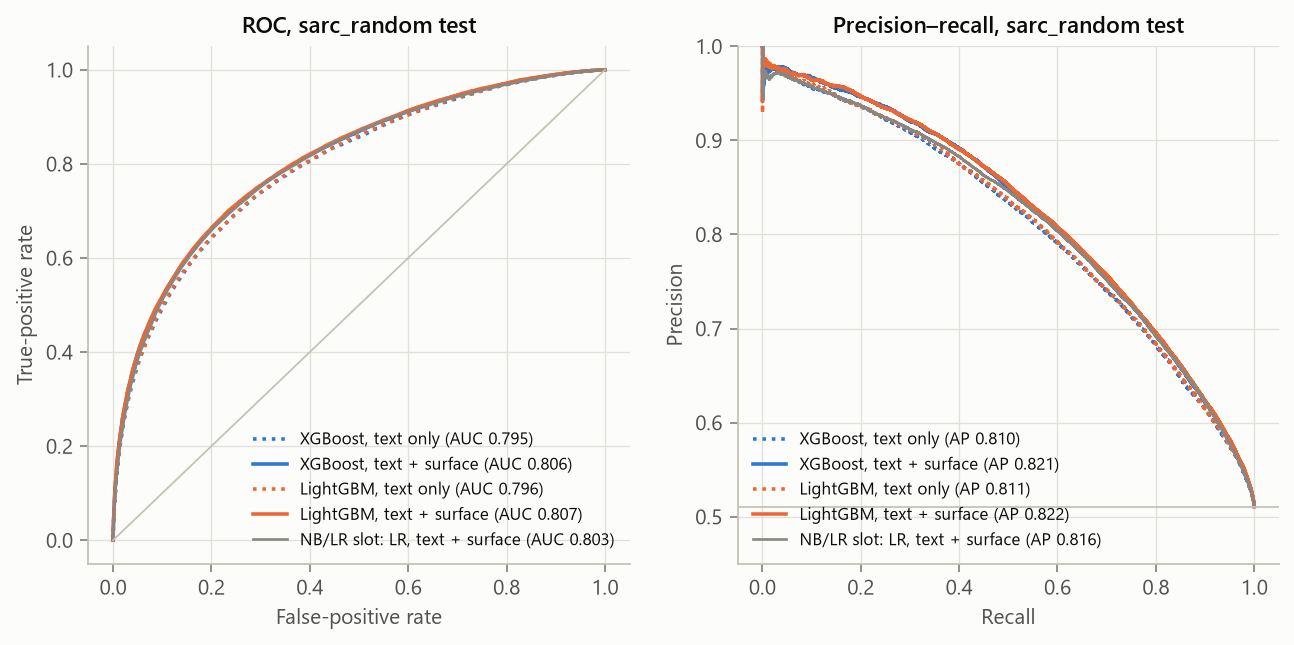

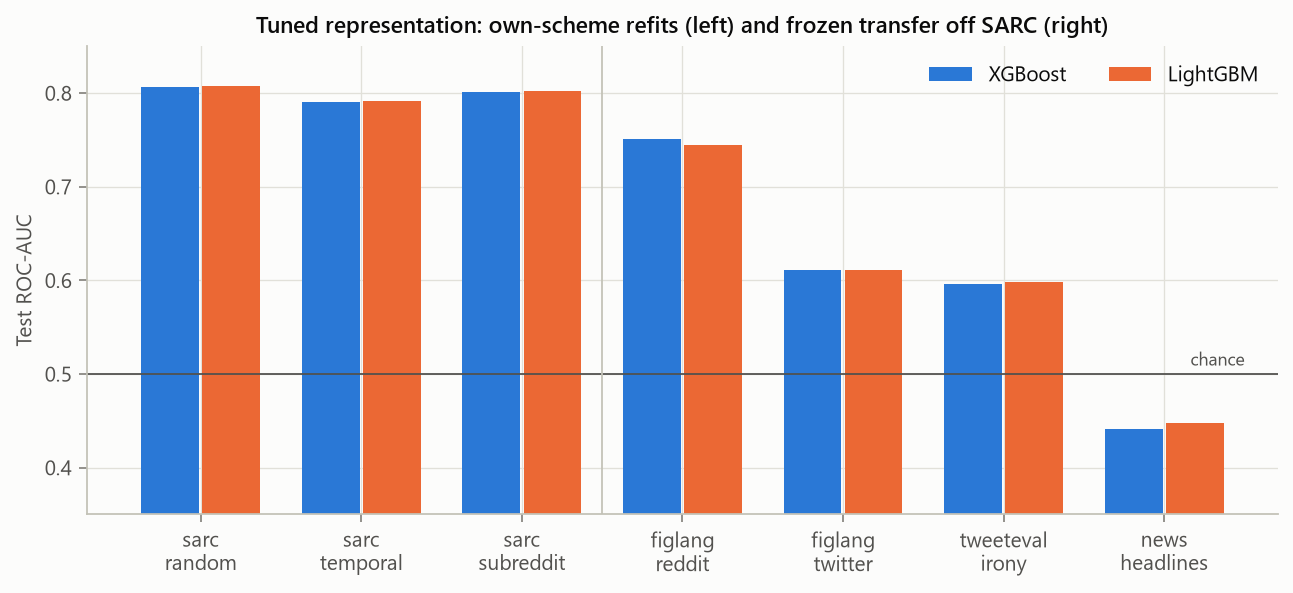

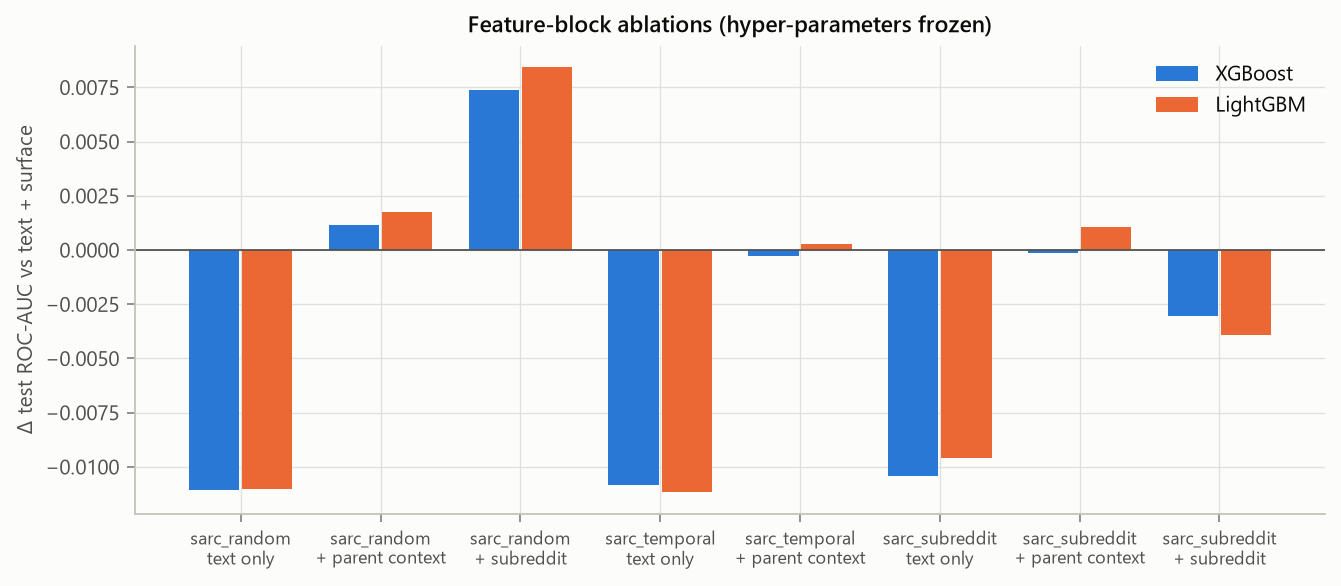

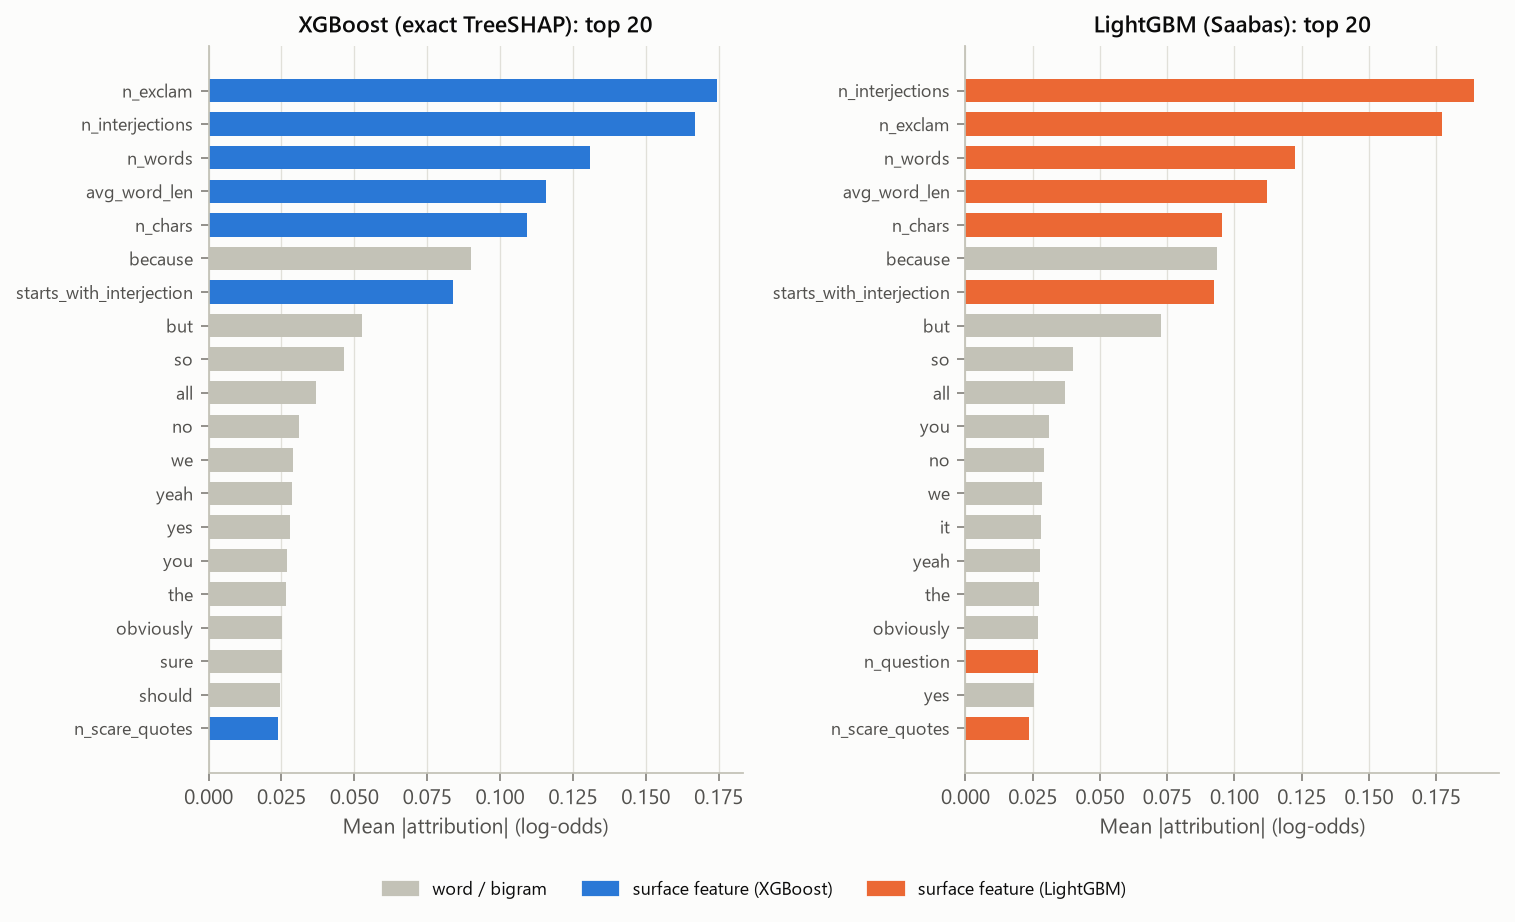

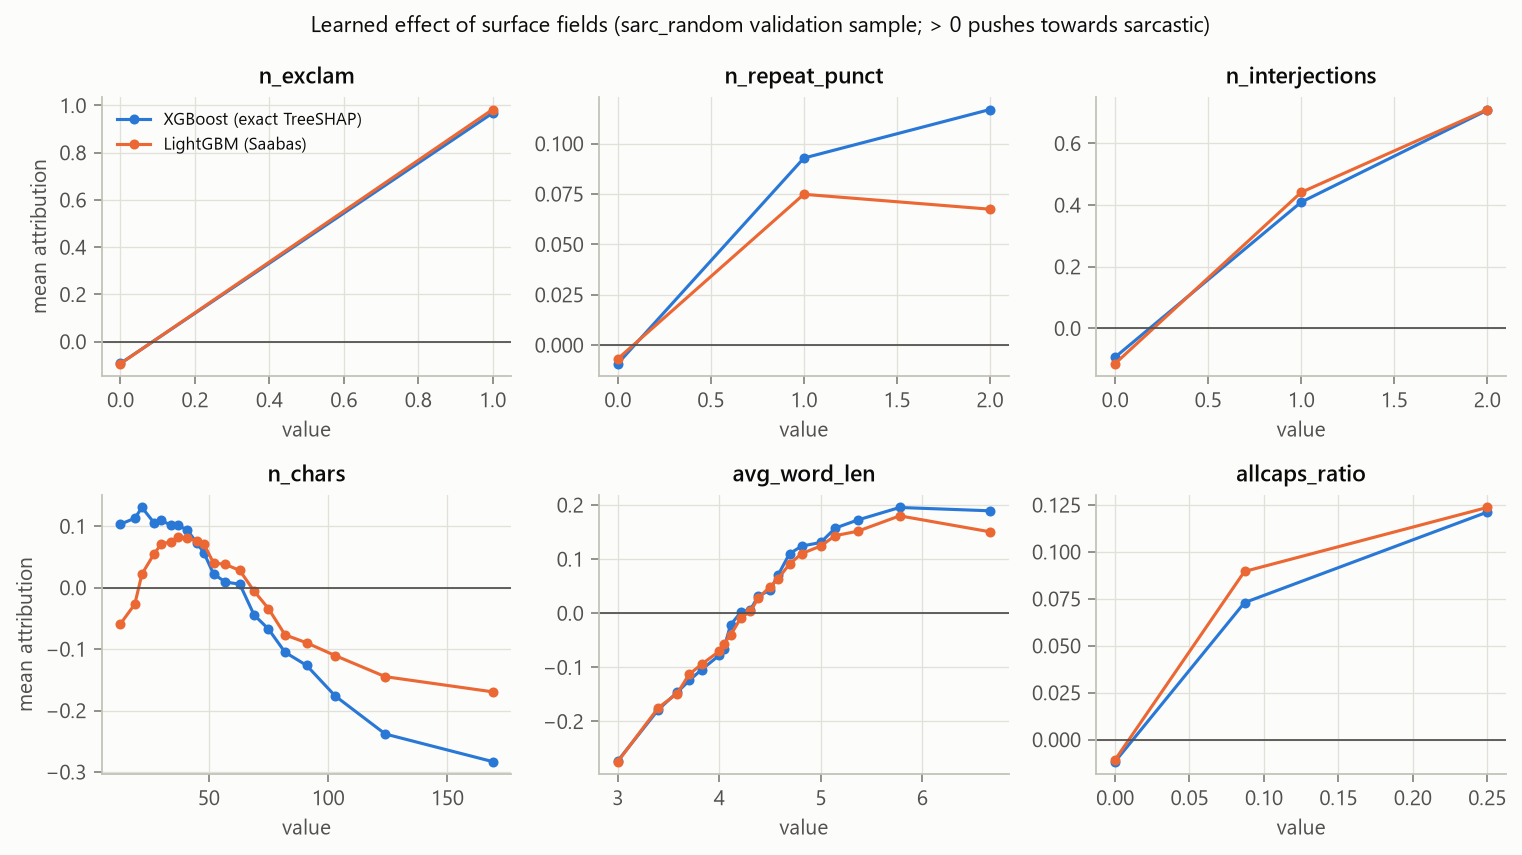

In [23]:
for name in ("G01_roc_pr", "G02_generalisation", "G03_ablation", "G04_top_features", "G05_effect_shapes"):
    display(Image(filename=str(FIGURES / f"{name}.png")))